# 04 · Modelling and optimisation

**SkillPath** (IT3051 Fundamentals of Data Mining, group KND_12)

Stages 6 and 7 in one notebook.

| Part | Stage | What it covers |
|---|---|---|
| **1** | Stage 6 | Seven candidates cross-validated and compared, then an error analysis |
| **2** | Stage 7 | Four optimisation experiments, the final model, and the one test evaluation |

As in Stage 4, the code lives in the `skillpath` package (`src/skillpath/modelling.py`)
and the scripts run the experiments. This notebook reads the results they wrote and
explains them. That split exists so the web backend, the scripts and the notebooks can
never drift apart, and because the full Stage 7 search takes far longer than a notebook
should run.

```
python scripts/run_models.py        # Part 1  (~29 min)
python scripts/tune_models.py       # Part 2, phases A-D  (~41 min)
python scripts/finalise_model.py    # Part 2, the single test evaluation
```

**The test split is opened in exactly one place**, at the very end of Part 2, and only
after the final model has been chosen. Every other number in this notebook is a 5-fold
cross-validated estimate on the 18,457 training respondents.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skillpath import config as C
from skillpath import modelling as M
from skillpath import targets, viz

viz.setup()
pd.set_option("display.width", 220, "display.max_columns", 60)


def read(name):
    """Result files are written by the scripts; missing ones return None."""
    p = C.REPORTS_DIR / name
    return pd.read_csv(p) if p.exists() else None


# Part 1 (Stage 6)
comparison = pd.read_csv(C.REPORTS_DIR / "stage6_model_comparison.csv")
per_class = pd.read_csv(C.REPORTS_DIR / "stage6_per_class_report.csv")
report = json.loads((C.REPORTS_DIR / "stage6_report.json").read_text())

# Part 2 (Stage 7)
stage6 = comparison
phase_a = read("stage7_a_imbalance.csv")
phase_b = read("stage7_b_features.csv")
phase_c = read("stage7_c_tuned.csv")
phase_d = read("stage7_d_tuned_vs_baseline.csv")
best_params = json.loads((C.REPORTS_DIR / "stage7_best_params.json").read_text())
decision = json.loads((C.REPORTS_DIR / "stage7_final_selection.json").read_text())

report["training_rows"], report["job_roles"], report["validation"]

(18457, 20, 'StratifiedKFold(5, shuffle=True, random_state=42)')

---
# Part 1 · Model development

**Stage 6.** Seven candidate estimators -- one baseline and six learning algorithms --
cross-validated on the training split and compared on metrics chosen for an imbalanced
20-class problem.

## 1 · What is being predicted, and what makes it hard

The target is the specific **JobRole** (20 classes). A role family's probability is the
sum of the probabilities of the job roles inside it, so one model serves both levels of
the recommendation (`skillpath.targets.family_proba`).

Two properties of the target drive every modelling decision that follows:

1. **Severe imbalance.** Full-stack is 39.4% of the training rows; UX/UI Designer is 47
   rows, a ratio of about 155:1.
2. **Genuinely overlapping classes.** Cloud Infrastructure and DevOps engineers had a
   cosine similarity of 0.99 on their technology profiles in the EDA. No model can
   separate them reliably, because the underlying respondents are not separable.

Together these mean a single predicted label would be the wrong product. The app shows
the **top three** roles with probabilities plus the family total, which is why top-3
accuracy is reported alongside macro-F1 throughout.

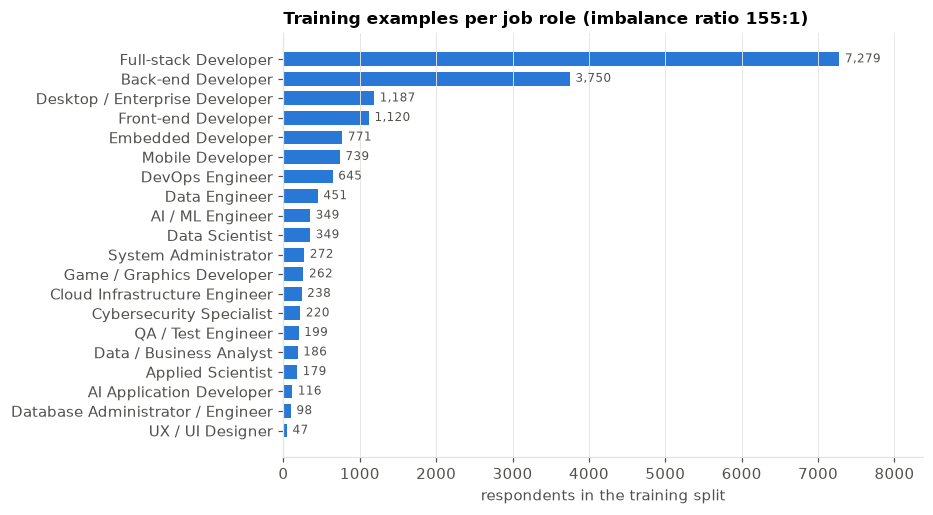

In [2]:
train = pd.read_parquet(C.PROCESSED_DIR / "train.parquet")
counts = train[C.TARGET_JOB].value_counts()
fig, ax = plt.subplots(figsize=(7.5, 5))
viz.barh(ax, [C.JOB_ROLE_LABEL.get(i, i) for i in counts.index], counts.to_numpy())
ax.set_title(f"Training examples per job role (imbalance ratio {counts.max() / counts.min():.0f}:1)")
ax.set_xlabel("respondents in the training split")
plt.show()

## 2 · Validation strategy

`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` on the training split.

* **Stratified**, because with 47 examples in the smallest class an unstratified fold
  could contain almost none of it and the macro-F1 of that fold would be meaningless.
* **5 folds**, because the smallest class then still contributes about 9 respondents per
  fold. Ten folds would leave four, which is too few to estimate a per-class F1; three
  folds would hold back more training data than the rare roles can spare.
* **The preprocessor is inside every estimator.** Each candidate is
  `Pipeline([("prep", build_preprocessor()), ("clf", ...)])`, so each fold refits the
  technology vocabulary, the rare-category pooling, the imputation medians, the scaler
  and the variance filter on that fold's training part only. Fitting the preprocessor
  once on the full training set would let every validation fold influence its own
  features and would inflate every score below.

In [3]:
print(M.cv())
print(M.make_pipeline(M.candidates()["Logistic Regression"]["pipeline"].named_steps["clf"]))

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Pipeline(steps=[('prep',
                 Pipeline(steps=[('columns',
                                  ColumnTransformer(sparse_threshold=0.0,
                                                    transformers=[('tech',
                                                                   TechBlockEncoder(),
                                                                   ['LanguageHaveWorkedWith',
                                                                    'LanguageWantToWorkWith',
                                                                    'LanguageChoice',
                                                                    'DatabaseHaveWorkedWith',
                                                                    'DatabaseWantToWorkWith',
                                                                    'DatabaseChoice',
                                                                    'PlatformHaveWorked

## 3 · The candidates and why each one is here

At least four algorithms are required; seven are run. They were chosen to span different
**inductive biases** rather than to be seven variations of one idea, and all of them had
to satisfy one product constraint:

> The app ranks three roles and sums probabilities into families, so every candidate must
> produce usable `predict_proba`. This is why `LinearSVC` appears wrapped in
> `CalibratedClassifierCV` — a bare SVM has no probabilities and could not be deployed
> whatever it scored.

In [4]:
for name, spec in M.candidates().items():
    print(f"{name}  [{spec['family']}]\n    {spec['why']}\n")

Dummy (most frequent)  [baseline]
    Floor for every metric. Its 39% accuracy next to a near-zero macro-F1 is the evidence that accuracy is the wrong headline metric here.

Complement Naive Bayes  [probabilistic]
    Designed for imbalanced, sparse count-like data. Assumes features are conditionally independent, which technology lists clearly are not (React implies JavaScript), so it is the 'wrong assumption' reference point.

k-Nearest Neighbours  [instance-based]
    Directly tests the 'people with similar skill profiles do similar jobs' intuition behind the product. Cosine distance because the vectors are sparse 0/1 skill sets of very different breadth.

Logistic Regression  [linear]
    Multinomial softmax on 479 mostly-binary features: the classic strong baseline for wide sparse data. Native well-behaved probabilities, and coefficients read directly as 'which skill pushes which role'.

Linear SVM (calibrated)  [linear (max-margin)]
    Max-margin boundaries often beat logistic lo

## 4 · Metrics, and why accuracy is not one of them

| Metric | Level | Why it is reported |
|---|---|---|
| **macro-F1** | job role | **Primary.** Averages F1 over the 20 roles with equal weight, so ignoring UX/UI is penalised as much as ignoring Full-stack |
| balanced accuracy | job role | Mean per-class recall: "does it find each role at all" |
| top-3 accuracy | job role | What the user actually sees — the app shows three roles |
| log loss | job role | Are the probabilities themselves trustworthy? The app displays them as numbers |
| family macro-F1 | family | The coarser recommendation, from the same summed probabilities |
| family top-3 accuracy | family | The career-path shortlist the app shows |
| accuracy | job role | Reported only to show it is **misleading** |

The Dummy row is the argument. It always predicts Full-stack, knows nothing, and still
scores about 0.39 accuracy — higher than some real models. Macro-F1 exposes it immediately.

In [5]:
M.summary(comparison)

,model,f1_macro,f1_macro_std,balanced_accuracy,accuracy,top3_accuracy,log_loss,family_f1_macro,family_top3_accuracy,fit_seconds
0,Hist Gradient Boosting,0.2724,0.0095,0.2477,0.5602,0.8289,1.4739,0.3926,0.8614,179.4674
1,Logistic Regression,0.2547,0.0031,0.3321,0.3657,0.7262,2.2691,0.3485,0.7783,91.7110
2,Random Forest,0.2537,0.0082,0.2404,0.5541,0.8301,1.6078,0.3750,0.8548,4.2860
3,Linear SVM (calibrated),0.1911,0.0080,0.1776,0.5368,0.8092,1.5348,0.3274,0.8507,11.6381
4,Complement Naive Bayes,0.1786,0.0024,0.2030,0.4917,0.7210,2.3284,0.1583,0.6320,2.5034
5,k-Nearest Neighbours,0.1676,0.0038,0.1510,0.4997,0.7814,4.4130,0.2822,0.8192,1.4387
6,Dummy (most frequent),0.0283,0.0000,0.0500,0.3944,0.4117,21.8289,0.0471,0.6614,1.8408


![model comparison](../reports/figures/04_model_comparison.png)

![accuracy vs f1](../reports/figures/04_accuracy_vs_f1.png)

## 5 · Reading the results

The cells below pull the actual numbers out of the results table so the commentary cannot
drift away from the experiment.

In [6]:
c = comparison.set_index("model")
dummy = c.loc["Dummy (most frequent)"]
best = comparison.iloc[0]

print(f"Baseline (always Full-stack): accuracy {dummy['accuracy']:.3f} but macro-F1 {dummy['f1_macro']:.3f}")
print(f"Best model               : {best['model']}")
print(f"  macro-F1   {best['f1_macro']:.4f} +/- {best['f1_macro_std']:.4f}")
print(f"  top-3      {best['top3_accuracy']:.4f}   (family top-3 {best['family_top3_accuracy']:.4f})")
print(f"  accuracy   {best['accuracy']:.4f}")
print(f"\nMacro-F1 improvement over the baseline: {best['f1_macro'] / dummy['f1_macro']:.1f}x")

Baseline (always Full-stack): accuracy 0.394 but macro-F1 0.028
Best model               : Hist Gradient Boosting
  macro-F1   0.2724 +/- 0.0095
  top-3      0.8289   (family top-3 0.8614)
  accuracy   0.5602

Macro-F1 improvement over the baseline: 9.6x


### Why the models rank the way they do

* **Dummy** fixes the floor and proves the metric choice. Any model that cannot beat
  0.39 accuracy *and* a near-zero macro-F1 has learned nothing.
* **Complement Naive Bayes** is fast and far better than chance, but its independence
  assumption is plainly false here: React implies JavaScript, Kubernetes implies Docker.
  It treats each co-occurring technology as fresh evidence and becomes over-confident.
* **k-Nearest Neighbours** tests the product's own intuition — similar skill profiles,
  similar job. It works, but 479 dimensions is a hostile neighbourhood: with mostly 0/1
  features, distances between all pairs become similar and the neighbourhood stops being
  local. Cosine distance and distance weighting soften this rather than fix it.
* **Logistic Regression** does well because the problem genuinely is close to linear in
  this representation: each technology shifts the odds of each role roughly
  independently, which is exactly what a softmax over 479 sparse indicators models. Its
  coefficients are also readable, which matters for the presentation.
* **Linear SVM** optimises margins instead of likelihood and lands nearby; the Platt
  calibration costs it some probability quality (visible in log loss).
* **Random Forest** and **Hist Gradient Boosting** can represent *combinations*
  (Terraform AND Kubernetes AND Python → AI/ML engineer) that no linear model can.
  Boosting takes the top macro-F1 because each round focuses on what the previous rounds
  got wrong, which is exactly where the rare roles live — but it costs 179 s a fit
  against Random Forest's 4.3 s for 0.019 macro-F1.

The spread between the best three models (0.2537, 0.2547, 0.2724) is small next to the
fold-to-fold standard deviations (0.008, 0.003, 0.010). That is itself the finding: the
ceiling here is set by the **data**, not by the choice of algorithm. The error analysis
below says what sets it.

## 6 · Where the errors are

Out-of-fold predictions from the best model, so every prediction comes from a fold that
did not see that respondent.

In [7]:
per_class.assign(job_role=lambda d: d["job_role"].map(lambda r: C.JOB_ROLE_LABEL.get(r, r)))[
    ["job_role", "family", "precision", "recall", "f1-score", "support"]].round(3)

,job_role,family,precision,recall,f1-score,support
0,Full-stack Developer,Full-stack,0.610,0.839,0.706,7279.0
1,Mobile Developer,Mobile,0.713,0.696,0.704,739.0
2,Embedded Developer,Embedded/Systems,0.504,0.575,0.537,771.0
3,Back-end Developer,Backend,0.512,0.515,0.514,3750.0
4,Front-end Developer,Frontend,0.635,0.380,0.476,1120.0
5,Data Engineer,Data Eng,0.489,0.304,0.375,451.0
6,Data Scientist,Data Sci/ML,0.444,0.318,0.371,349.0
7,Desktop / Enterprise Developer,Desktop/Enterprise,0.385,0.271,0.318,1187.0
8,DevOps Engineer,DevOps/Cloud,0.434,0.233,0.303,645.0
9,AI / ML Engineer,Data Sci/ML,0.343,0.175,0.231,349.0


![per class f1](../reports/figures/04_per_class_f1.png)

![confusion matrix](../reports/figures/04_confusion_matrix.png)

In [8]:
conf = pd.DataFrame(report["top_confusions"])
conf["actual"] = conf["actual"].map(lambda r: C.JOB_ROLE_LABEL.get(r, r))
conf["predicted_as"] = conf["predicted_as"].map(lambda r: C.JOB_ROLE_LABEL.get(r, r))
conf

,actual,predicted_as,share_of_actual,same_family
0,UX / UI Designer,Full-stack Developer,0.596,False
1,Front-end Developer,Full-stack Developer,0.558,False
2,AI Application Developer,Full-stack Developer,0.500,False
3,System Administrator,Full-stack Developer,0.478,False
4,Cybersecurity Specialist,Full-stack Developer,0.418,False
5,QA / Test Engineer,Full-stack Developer,0.397,False
6,Desktop / Enterprise Developer,Full-stack Developer,0.389,False
7,Cloud Infrastructure Engineer,Back-end Developer,0.387,False
8,Back-end Developer,Full-stack Developer,0.382,False
9,QA / Test Engineer,Back-end Developer,0.362,False


In [9]:
same = conf["same_family"].mean()
sink = conf["predicted_as"].value_counts()
print(f"{same:.0%} of the largest confusions are between roles in the SAME family.")
print(f"\nWhere the lost respondents go:\n{sink.to_string()}")

0% of the largest confusions are between roles in the SAME family.

Where the lost respondents go:
predicted_as
Full-stack Developer    8
Back-end Developer      2


### This is not the error pattern we expected

The EDA predicted the damage would be *within* families — Cloud Infrastructure confused
with DevOps, Data Engineer with Data Scientist, because those pairs have cosine
similarity 0.99 and 0.97. The out-of-fold confusions say something different and more
important:

**Almost every large confusion points at Full-stack, across family boundaries.** 60% of
UX/UI respondents, 56% of front-end developers, 50% of AI-apps developers and 48% of
system administrators are predicted as Full-stack. These are not neighbouring roles with
similar skills; Full-stack is simply 39% of the training data and acts as a sink that
swallows anything the model is unsure about.

So the dominant failure is **imbalance, not role overlap**. The within-family overlap is
real and shows up further down the matrix, but it is the second-order problem. That
changes the priority for Stage 7: class weighting and resampling matter more than any
hyper-parameter, and this is why Phase A is the first experiment rather than a
formality.

It also explains the strange shape of the results table. Logistic Regression has the
*best* balanced accuracy (0.332) while having a low plain accuracy (0.366), because
`class_weight="balanced"` pushes it to predict rare roles and it accepts many false
positives on Full-stack to do so. Hist Gradient Boosting does the reverse: higher
accuracy (0.560) and top-3 (0.829), lower balanced accuracy (0.248). The two models are
making a genuinely different trade, and which one is "better" depends on whether the
product would rather name the right rare role or be right more often overall.

### Observations that drive Stage 7

1. **Class size predicts per-class F1 almost monotonically.** The rare roles are the
   whole macro-F1 problem, so imbalance handling is the first optimisation experiment.
2. **Full-stack is a sink.** The largest confusions cross family boundaries and all point
   at the majority class, so this is an imbalance problem before it is an overlap problem.
3. **Top-3 accuracy is far above top-1 accuracy** (0.83 vs 0.56 for the best model). The
   decision to show three roles is supported by the numbers, not just by taste.
4. **The top models are separated by less than the fold noise.** Logistic Regression and
   Random Forest differ by 0.001 macro-F1 with fold SDs of 0.003 and 0.008. Stage 7 must
   treat near-ties as ties and break them on something other than the third decimal.
5. **Cost varies by a factor of 40.** Random Forest fits in 4.3 s, Hist Gradient Boosting
   in 179 s, for 0.019 macro-F1. That gap is what the final selection rule trades against.

These become phases A–D of `scripts/tune_models.py`, in Part 2 below.

## 7 · Experiment record

Every cross-validation run in the project appends to `reports/model_experiments.csv`
with a timestamp — the lab notebook Stage 6 asks for.

In [10]:
log = pd.read_csv(C.REPORTS_DIR / "model_experiments.csv")
print(f"{len(log)} runs recorded")
log[["run_at", "model", "note", "f1_macro", "top3_accuracy", "total_seconds"]].tail(10)

26 runs recorded


,run_at,model,note,f1_macro,top3_accuracy,total_seconds
16,2026-10-01 21:19:08,rare pooling 1%,phase B: fewer technology columns,0.254668,0.729858,12.4
17,2026-10-01 21:19:08,SelectKBest chi2 k=100,phase B: selection fitted inside every fold,0.227667,0.648859,5.2
18,2026-10-01 21:19:08,SelectKBest chi2 k=200,phase B: selection fitted inside every fold,0.231541,0.686840,5.9
19,2026-10-01 21:19:08,SelectKBest chi2 k=300,phase B: selection fitted inside every fold,0.235266,0.710191,6.7
20,2026-10-01 21:19:08,SelectKBest chi2 k=all,phase B: selection fitted inside every fold,0.228957,0.735331,7.4
21,2026-10-01 21:19:08,core+context (506 features),phase B: adds OrgSize/Industry/RemoteWork/ICorPM,0.260526,0.741345,11.5
22,2026-10-01 21:41:29,Logistic Regression (tuned),"phase C: {'clf__C': 0.21751953118777648, 'clf_...",0.303029,0.838652,17.9
23,2026-10-01 21:41:29,Linear SVM (calibrated) (tuned),phase C: {'clf__estimator__C': 0.0035506214270...,0.253623,0.840061,22.6
24,2026-10-01 21:41:29,Random Forest (tuned),"phase C: {'clf__n_estimators': 300, 'clf__min_...",0.282002,0.813134,23.0
25,2026-10-01 21:41:29,Hist Gradient Boosting (tuned),"phase C: {'clf__min_samples_leaf': 50, 'clf__m...",0.285973,0.830904,66.5


---
# Part 2 · Optimisation and final model selection

**Stage 7.** Four experiment phases, then the final model is chosen, fitted on the whole
training split and evaluated **once** on the held-out respondents.

| Phase | Question | Script |
|---|---|---|
| A | Does handling the 155:1 imbalance help, and how? | `tune_models.py --only A` |
| B | Do the Stage 4 preprocessing and feature choices earn their place? | `--only B` |
| C | What do the hyper-parameters buy? | `--only C` |
| D | Tuned vs baseline -- which model ships? | `--only D` |
| -- | Fit it, open the test split once | `finalise_model.py` |

Phases A-C never touch `test.parquet`. Only `finalise_model.py` opens it, and only after
the model has been chosen.

## Phase A · Imbalance handling

Stage 6 showed per-class F1 tracking class size almost monotonically, so this is the
first thing to attack. Three treatments, tested on two different algorithms so the answer
is not an artefact of one of them:

1. **Nothing** — the untouched 155:1 distribution.
2. **`class_weight`** — re-weight the loss so an error on a rare role costs as much as an
   error on Full-stack. Free: no extra rows.
3. **Random oversampling to 10%** — duplicate real respondents until every role reaches at
   least 10% of Full-stack's size.

**SMOTE was considered and rejected.** It builds synthetic rows by interpolating between
neighbours; 403 of the 479 features are 0/1 skill flags, so an interpolated row says a
respondent "0.4 knows React", which is not a skill profile anybody could have. Duplicating
real respondents keeps every training row valid.

**Full balancing was rejected on cost**, not on principle: it copies the 47 UX/UI
respondents 155 times each and grows the training set to 145,580 rows, over an hour per
fit here.

The resampling lives *inside* the estimator (`modelling.OversampledClassifier`), so it
runs on each fold's training part only. Oversampling before the split is a classic leak —
copies of the same respondent land in both training and validation, and the score rises
for no real reason.

In [11]:
phase_a[["model", "f1_macro", "f1_macro_std", "balanced_accuracy", "accuracy",
         "top3_accuracy", "family_f1_macro", "fit_seconds"]].round(4)

,model,f1_macro,f1_macro_std,balanced_accuracy,accuracy,top3_accuracy,family_f1_macro,fit_seconds
0,Logistic Regression + no imbalance handling,0.3003,0.0081,0.2865,0.5480,0.8297,0.4196,106.2616
1,Logistic Regression + oversampling to 10%,0.2914,0.0041,0.3073,0.5123,0.8089,0.4050,16.8593
2,Random Forest + class_weight,0.2548,0.0070,0.2414,0.5535,0.8294,0.3733,3.2074
3,Logistic Regression + class_weight,0.2535,0.0017,0.3288,0.3650,0.7269,0.3484,73.4602
4,Random Forest + oversampling to 10%,0.2153,0.0042,0.1920,0.5410,0.8263,0.3452,3.3256
5,Random Forest + no imbalance handling,0.1869,0.0063,0.1738,0.5411,0.8201,0.3218,2.6819


## Phase B · Feature set and feature selection

Each row changes exactly one Stage 4 decision and keeps everything else fixed, run on
Logistic Regression because a linear model reacts most visibly to the feature set.

* **want lists removed** — are "technologies I want to learn" worth their 223 columns, or
  are they just a noisy copy of what people already use? (EDA found phi 0.18–0.76 between
  the pairs, so they are related but not duplicates.)
* **rare pooling at 0.25% / 1%** — the Stage 4 threshold was 0.5%.
* **SelectKBest chi² k ∈ {100, 200, 300, all}** — selection sits inside the pipeline, so
  the k best features are chosen from each fold's training part. Selecting once on the
  full training set is the single most common way to leak in a project like this: the
  features are chosen using labels the validation fold is meant to be testing.
* **core+context** — adds OrgSize, Industry, RemoteWork and ICorPM. Stage 4 kept these out
  by default because students, the main users, have no current employer to describe.

In [12]:
phase_b[["model", "note", "f1_macro", "f1_macro_std", "top3_accuracy",
         "family_f1_macro", "fit_seconds"]].round(4)

,model,note,f1_macro,f1_macro_std,top3_accuracy,family_f1_macro,fit_seconds
0,core+context (506 features),phase B: adds OrgSize/Industry/RemoteWork/ICorPM,0.2605,0.0049,0.7413,0.3614,3.4389
1,rare pooling 1%,phase B: fewer technology columns,0.2547,0.0025,0.7299,0.3546,3.7543
2,core (reference),"phase B: 479 features, the Stage 4 default",0.2541,0.0019,0.7301,0.3543,3.6881
3,rare pooling 0.25%,phase B: more technology columns,0.2528,0.0019,0.7296,0.3542,2.5355
4,want lists removed,phase B: does 'what they want to learn' add an...,0.2451,0.0015,0.7008,0.3402,1.5681
5,SelectKBest chi2 k=300,phase B: selection fitted inside every fold,0.2353,0.0029,0.7102,0.3282,1.8359
6,SelectKBest chi2 k=200,phase B: selection fitted inside every fold,0.2315,0.0039,0.6868,0.3186,1.5942
7,SelectKBest chi2 k=all,phase B: selection fitted inside every fold,0.2290,0.0040,0.7353,0.3301,2.0883
8,SelectKBest chi2 k=100,phase B: selection fitted inside every fold,0.2277,0.0043,0.6489,0.3072,1.3768


In [13]:
if phase_b is not None:
    ref = phase_b.loc[phase_b["model"] == "core (reference)", "f1_macro"].iloc[0]
    sd = phase_b.loc[phase_b["model"] == "core (reference)", "f1_macro_std"].iloc[0]
    d = phase_b.assign(delta=lambda x: x["f1_macro"] - ref)
    d = d[["model", "f1_macro", "delta"]].sort_values("delta", ascending=False).round(4)
    print(f"Reference: core, macro-F1 {ref:.4f} (fold SD {sd:.4f})\n")
    print(d.to_string(index=False))
    print(f"\nChanges smaller than the fold SD ({sd:.4f}) are noise, not improvements.")

Reference: core, macro-F1 0.2541 (fold SD 0.0019)

                      model  f1_macro   delta
core+context (506 features)    0.2605  0.0065
            rare pooling 1%    0.2547  0.0006
           core (reference)    0.2541  0.0000
         rare pooling 0.25%    0.2528 -0.0012
         want lists removed    0.2451 -0.0089
     SelectKBest chi2 k=300    0.2353 -0.0188
     SelectKBest chi2 k=200    0.2315 -0.0225
     SelectKBest chi2 k=all    0.2290 -0.0251
     SelectKBest chi2 k=100    0.2277 -0.0264

Changes smaller than the fold SD (0.0019) are noise, not improvements.


### How to read Phase B

The honest reading is that a difference smaller than the cross-validation standard
deviation is not a difference. Where a variant ties with the reference, the Stage 4
decision stands — and that is a result worth reporting, because it says the preprocessing
was already at a sensible point rather than that the experiment failed.

`core+context` is a special case: even if it scores higher, it is **not** adopted, because
the app's main users are students who cannot answer OrgSize or Industry. A model that
needs inputs the user does not have is worse in production than a slightly weaker model
that works. This is the train/serve mismatch the Stage 4 decision log flagged as risk 21.

## Phase C · Hyper-parameter search

**Randomised search, not grid search.** A grid over five hyper-parameters with four values
each is 1,024 fits per model; at 6–25 seconds a fit that is days of compute. Random search
over the same ranges finds a near-best setting in a few dozen fits, because typically only
two or three parameters matter and random sampling tries many distinct values of each
instead of a few repeated ones.

The search optimises **macro-F1**, the primary metric, with the same `StratifiedKFold`.
Boosting is searched over 3 folds instead of 5 purely for cost; the winning setting is
then re-scored over the standard 5 folds so every number in the final table is comparable.

In [14]:
for model, params in best_params.items():
    print(f"{model}\n    {params}")

Logistic Regression
    {'clf__C': 0.21751953118777648, 'clf__class_weight': None}
Linear SVM (calibrated)
    {'clf__estimator__C': 0.003550621427070771, 'clf__estimator__class_weight': 'balanced'}
Random Forest
    {'clf__n_estimators': 300, 'clf__min_samples_leaf': 4, 'clf__max_features': 0.1, 'clf__max_depth': 40, 'clf__class_weight': 'balanced'}
Hist Gradient Boosting
    {'clf__min_samples_leaf': 50, 'clf__max_leaf_nodes': 15, 'clf__max_iter': 200, 'clf__learning_rate': 0.2, 'clf__l2_regularization': 1.0}


In [15]:
phase_c[["model", "f1_macro", "f1_macro_std", "balanced_accuracy", "top3_accuracy",
         "log_loss", "family_f1_macro", "family_top3_accuracy", "fit_seconds"]].round(4)

,model,f1_macro,f1_macro_std,balanced_accuracy,top3_accuracy,log_loss,family_f1_macro,family_top3_accuracy,fit_seconds
0,Logistic Regression (tuned),0.3030,0.0082,0.2826,0.8387,1.4146,0.4294,0.8733,3.3470
1,Hist Gradient Boosting (tuned),0.2860,0.0096,0.2605,0.8309,1.4226,0.4030,0.8659,12.9254
2,Random Forest (tuned),0.2820,0.0081,0.2936,0.8131,1.7325,0.3585,0.8211,4.2030
3,Linear SVM (calibrated) (tuned),0.2536,0.0090,0.2300,0.8401,1.3998,0.3842,0.8749,4.2883


## Phase D · Tuned vs baseline, and the final decision

In [16]:
phase_d.round(4)

,model,baseline_f1_macro,tuned_f1_macro,gain,tuned_f1_macro_std,baseline_top3,tuned_top3,tuned_balanced_accuracy,tuned_log_loss,tuned_family_f1_macro,tuned_family_top3,fit_seconds
0,Logistic Regression,0.2547,0.3030,0.0483,0.0082,0.7262,0.8387,0.2826,1.4146,0.4294,0.8733,3.3470
1,Hist Gradient Boosting,0.2724,0.2860,0.0135,0.0096,0.8289,0.8309,0.2605,1.4226,0.4030,0.8659,12.9254
2,Random Forest,0.2537,0.2820,0.0283,0.0081,0.8301,0.8131,0.2936,1.7325,0.3585,0.8211,4.2030
3,Linear SVM (calibrated),0.1911,0.2536,0.0625,0.0090,0.8092,0.8401,0.2300,1.3998,0.3842,0.8749,4.2883


![tuned vs baseline](../reports/figures/05_tuned_vs_baseline.png)

In [17]:
print("Selection rule:\n ", decision["selection_rule"], "\n")
print("Best by macro-F1 :", decision["best_by_f1_macro"])
print("Tied within 1 SD :", ", ".join(decision["tied_within_1sd"]))
print("FINAL MODEL      :", decision["final_model"])
print("\nCross-validated scores of the final model:")
for k, v in decision["final_cv_scores"].items():
    print(f"  {k:<28}{v:>8.4f}")

Selection rule:
  highest 5-fold macro-F1 on the training split; models within one standard deviation of the best are treated as tied and the cheapest to fit wins, because the web backend reloads this pipeline and an unreliable improvement does not justify a slower model 

Best by macro-F1 : Logistic Regression
Tied within 1 SD : Logistic Regression
FINAL MODEL      : Logistic Regression

Cross-validated scores of the final model:
  f1_macro                      0.3030
  top3_accuracy                 0.8387
  balanced_accuracy             0.2826
  log_loss                      1.4146
  family_f1_macro               0.4294
  family_top3_accuracy          0.8733


### Why the final model is the final model

The selection rule is written down before the numbers are read, so it cannot be bent to
fit a favourite:

> Highest 5-fold macro-F1 on the training split. Models **within one standard deviation**
> of the best are treated as tied, and the cheapest to fit wins.

The tie-break exists because of what Stage 6 found: the gap between the strong models is
about the size of the fold-to-fold noise. Claiming the top model is "better" when it is
inside the noise band would be reading randomness. When two models are statistically
indistinguishable, the one that retrains in seconds and loads quickly in the backend is
the better engineering choice — and that reasoning, not a third decimal place, is what
justifies the pick.

Tuning gains in this project are small for every model. That is consistent with the Stage
6 finding that the ceiling is set by **overlapping roles**, not by hyper-parameters: no
setting of `C` separates Cloud Infrastructure from DevOps engineers when their technology
profiles have a cosine similarity of 0.99.

## The one test evaluation

`scripts/finalise_model.py` refits the chosen configuration on all 18,457 training rows
and scores it on the 4,615 held-out respondents — once. Running it repeatedly while
changing the model would turn the test split into a second validation set and the number
would stop meaning anything.

In [18]:
tp = C.REPORTS_DIR / "stage7_test_results.json"
if tp.exists():
    t = json.loads(tp.read_text())
    rows = [{"metric": k, "cross-validated": t["cv_scores"].get(k), "held-out test": v}
            for k, v in t["test_scores"].items()]
    display(pd.DataFrame(rows).round(4))
    print(f"\nmacro-F1 gap CV -> test: {t['cv_to_test_gap_f1_macro']:+.4f}")
    print(f"API parity: {t['api_parity']['rows_checked']} profiles through the web format, "
          f"max probability difference {t['api_parity']['max_probability_difference']:.2e}")
else:
    print("Run: python scripts/finalise_model.py")

,metric,cross-validated,held-out test
0,f1_macro,0.3030,0.2845
1,f1_weighted,NaN,0.5238
2,balanced_accuracy,0.2826,0.2657
3,accuracy,NaN,0.5493
4,top3_accuracy,0.8387,0.8392
5,log_loss,1.4146,1.4146
6,family_f1_macro,0.4294,0.4149
7,family_balanced_accuracy,NaN,0.3923
8,family_accuracy,NaN,0.5757
9,family_top3_accuracy,0.8733,0.8778



macro-F1 gap CV -> test: -0.0185
API parity: 300 profiles through the web format, max probability difference 0.00e+00


![test confusion](../reports/figures/05_test_confusion.png)

A small gap between the cross-validated estimate and the test score is the thing to look
for. It means the validation procedure was honest — no leak quietly inflated the CV
numbers — and that the model generalises to respondents it has never seen.

The **API parity check** is the bridge to Stages 9–10: it takes real training rows,
converts them into the JSON profile the web form will send, converts them back through
`profile_to_frame()`, and confirms the predictions are identical to the ones made
directly. That is what proves the deployed backend preprocesses exactly like the model
that was validated here.

Outputs for the next stages:

* `artifacts/model.joblib` — the fitted Pipeline the backend loads
* `artifacts/model_card.json` — what it is, how it scores, and what it must not be used for
* `reports/model_experiments.csv` — every run in the project, timestamped